- Why attention exists
- The Query, Key, Value abstraction
- A single attention calculation
- Deriving scaled dot-product attention
- Why divide by dk?
- Softmax in attention
- Weighted aggregation
- Causal masking
- Padding masks
- Self-attention vs cross-attention
- Multi-head attention
- Positional information
- Full mathematical formulation
- Implementation from scratch

Before we continue this section i would love recommend you to check out [3Blue1Brown's Attention in Transformers](https://www.youtube.com/watch?v=eMlx5fFNoYc). This video provides an intuitive visual representation of how Query, Key, and Value matrices interact to update contextual embeddings.

**Section 1: The "Why" — Moving Beyond Static Embeddings**

* **The Problem with Embeddings Alone:** Explain that while token + positional embeddings provide a static representation of a word, language is context-dependent (e.g., "bank" in "river bank" vs. "bank account").

Now that we have transformed raw text into numerical tokens and mapped those tokens into high-dimensional vector spaces, our neural network can process language as numbers rather than characters. However, a crucial challenge remains: contextual understanding.

Consider the sentence: “The animal didn’t cross the street because it was too tired.” How does a machine determine what “it” refers to, the animal or the street? Similarly, consider the word “bank.” How does the model determine whether bank refers to a financial institution or the edge of a river?

The meaning of a word cannot always be determined from the word itself. Its meaning depends heavily on the surrounding context and its relationship to other words in the sequence. This is the problem that  [attention mechanism](https://en.wikipedia.org/wiki/Attention_(machine_learning)) is designed to address.


* **The Attention Solution:** The [attention mechanism](https://en.wikipedia.org/wiki/Attention_(machine_learning)) is a mathematical technique in neural networks that mimics human cognitive focus. Instead of processing every word or token in isolation, it allows a model to look at the entire context at once and dynamically calculate how strongly each word relates to every other word in a sequence.

Consider the example : *"The trophy didn’t fit in the suitcase because **it** was too large."*

The word **"it"** starts as a static vector containing generic language information about the word "it". On its own, the vector doesn't know whether "it" refers to the bank, the loan, or the person applying.

To know the contextual meaning of "it" we have to compute the Query ($Q$), Key ($K$), Value ($V$) for each token embedding to allow "it" to ask the surrounding words what they represent, score how relevant each word is to its query, and combine their information to update "it" with its exact contextual meaning**:
* **Query ($Q$) for "it"**: Asking the rest of the sentence, *"Who or what does 'it' refer to?"*
* **Keys ($K$) for surrounding tokens**: Each word advertises its semantic features (e.g., **"bank"** = entity/financial, **"loan"** = financial object, **"credit"** = financial score).

Calculating Attention Scores **($Q \cdot K^T / \sqrt{d_k}$)**:
The model compares the Query for **"it"** against the Keys of all other words to calculate similarity scores:
* **"it" $\rightarrow$ "bank"**: High relevance score (e.g., **0.78**)
* **"it" $\rightarrow$ "loan"**: Low relevance score (e.g., **0.12**)
* **"it" $\rightarrow$ "credit"**: Medium relevance score (e.g., **0.08**)
* **"it" $\rightarrow$ "because"**: Very low relevance score (e.g., **0.02**)


**Softmax & Weighted Sum ($V$)**:
The raw scores pass through a softmax function to turn them into probabilities that sum to 1. The model then takes a weighted combination of all Value vectors:

$$\text{Updated Vector for 'it'} = (0.78 \times V_{\text{bank}}) + (0.12 \times V_{\text{loan}}) + (0.08 \times V_{\text{credit}}) + \dots$$

**The Result**
After the attention step, the output vector for **"it"** is no longer just a generic pronoun representation. It is now dynamically updated with features pulled directly from **"bank"**, allowing the downstream layers of the Transformer to treat **"it"** as referring to the **bank**.

Don't worry if all of this feels high-level right now, this is just the big-picture view of how attention works! Below we'll dive deep into each component, break down the exact mathematics, and build every piece from scratch.

---

Lets start from the beginning : 

To make this clear and visual, let's trace a simple sentence through our pipeline using subword tokenization:"The trophy didn't fit in the suitcase because it was too large."

After passing these subword tokens through our embedding layer, each token is mapped to a vector, forming an initial Embedding Matrix ($X$). At this stage, every vector represents a standalone word embedding meaning the pronoun "it" has a generic representation that doesn't yet know whether it refers to the trophy or the suitcase.

\begin{align*}
\text{Tokens} & \qquad \qquad \text{Embedding Matrix } X \in \mathbb{R}^{13 \times d_{\text{model}}} \\[6pt]
\begin{matrix}
\text{\small "The"} \\
\text{\small "trophy"} \\
\vdots \\
\text{\small "suitcase"} \\
\vdots \\
\mathbf{\text{\small "it"}} \\
\vdots \\
\text{\small "large"}
\end{matrix}
& \begin{matrix}
\rightarrow \\
\rightarrow \\
\vdots \\
\rightarrow \\
\vdots \\
\mathbf{\rightarrow} \\
\vdots \\
\rightarrow
\end{matrix}
\begin{bmatrix}
x_{1,1} & x_{1,2} & \dots & x_{1,d} \\
x_{2,1} & x_{2,2} & \dots & x_{2,d} \\
\vdots & \vdots & \ddots & \vdots \\
x_{8,1} & x_{8,2} & \dots & x_{8,d} \\
\vdots & \vdots & \ddots & \vdots \\
\mathbf{x_{10,1}} & \mathbf{x_{10,2}} & \mathbf{\dots} & \mathbf{x_{10,d}} \\
\vdots & \vdots & \ddots & \vdots \\
x_{13,1} & x_{13,2} & \dots & x_{13,d}
\end{bmatrix}
\end{align*}

In real Transformer models, tokens are embedded into high-dimensional spaces (such as $d_{\text{model}} = 512$ or $768$). Because humans cannot intuitively visualize space beyond three dimensions, we will simplify our embedding dimension to $d_{\text{model}} = 3$ so we can plot our tokens on a standard 3D Cartesian plane. 

- It is important to remember that when a network is first initialized, the embedding weights are generated randomly. 
- Words with similar meanings or grammatical roles (like "trophy" and "suitcase") are not clustered together yet. 
- The pronoun "it" points in a random direction that carries no contextual awareness

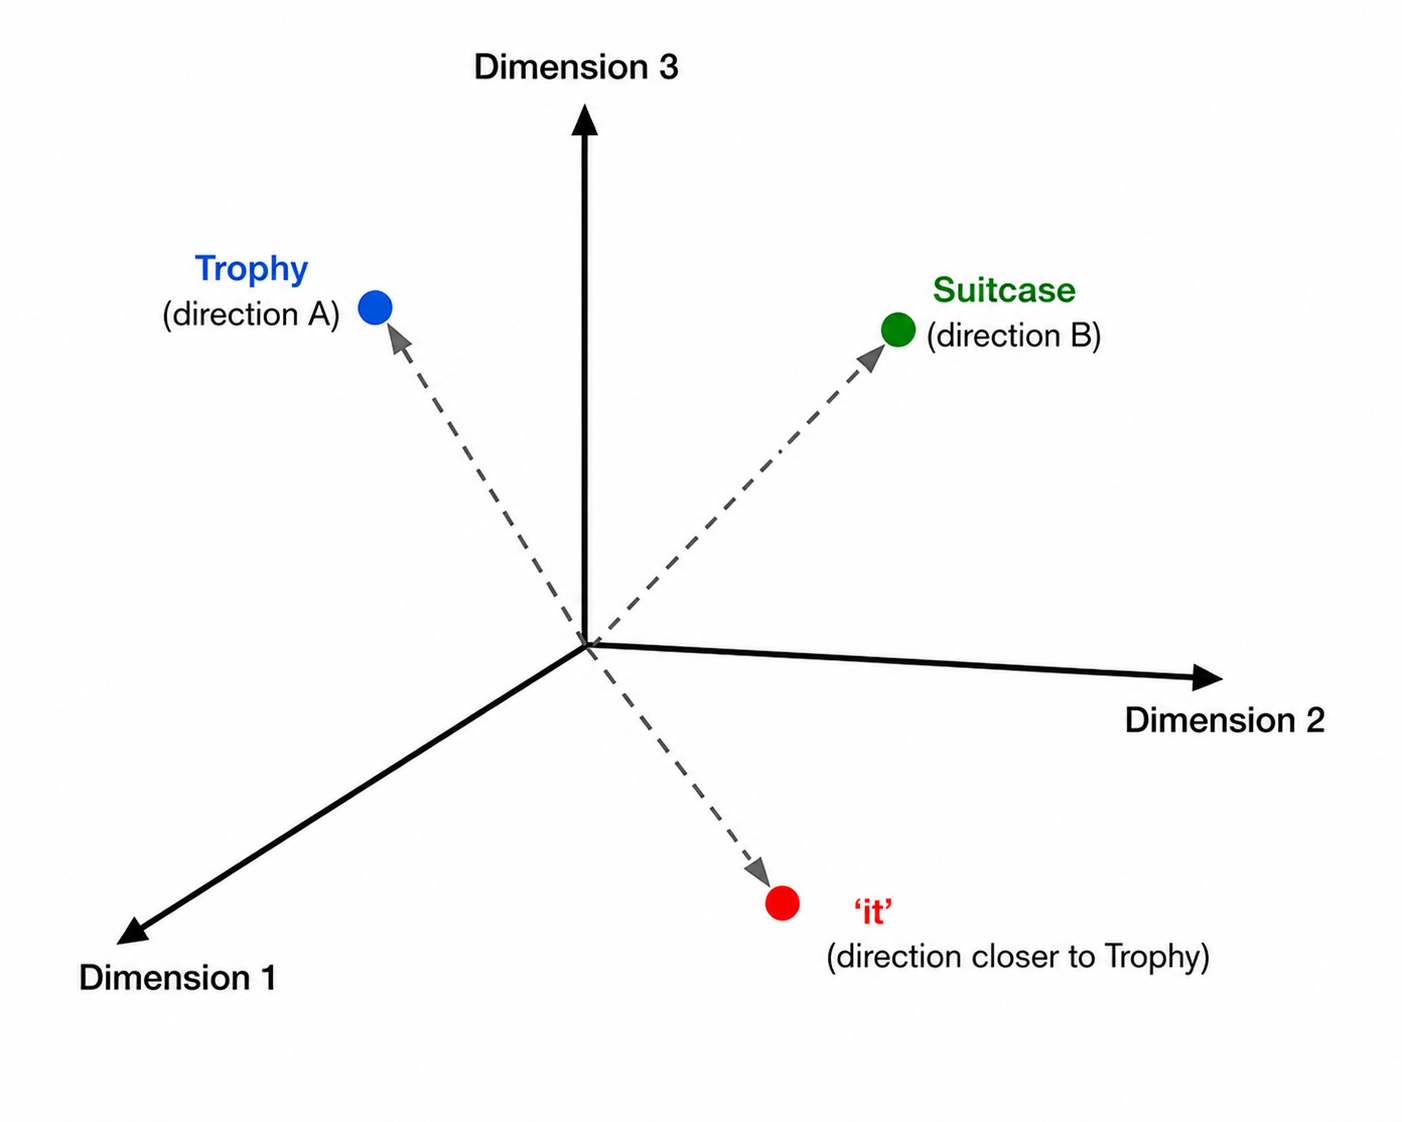


Now that we have our initial embedding matrix $X$, we need a mechanism to let tokens search for context. Rather than comparing raw word embeddings directly, the Transformer projects each token vector into three distinct vector spaces:
- Query ($Q$): Represents what a token is looking for. (What am I looking for?”)
- Key ($K$): Represents what features or labels a token offers to others.(What information do I represent?)
- Value ($V$): Represents the actual contextual information a token passes along if matched.(Here is the actual information you can take from me.) We will look at Value ($V$) in a second first lets focus on Query ($Q$) and Key ($K$) :)  

![image.png](/home/mrceo/Documents/Transformer-Implementation/static/query_opp_matrix.png)


For any specific token $i$ (where $Ei = E_1, E_2, ..., E_N$), its individual Query vector $Q_i$ is calculated by multiplying its embedding vector $E_i$ by the learned query weight matrix $W^Q \in \mathbb{R}^{d_{\text{model}} \times d_k}$:$$Q_i = E_i W^Q$$

Similarly, its individual Key and Value vectors are computed using their respective projection weight matrices $W^K \in \mathbb{R}^{d_{\text{model}} \times d_k}$ and $W^V \in \mathbb{R}^{d_{\text{model}} \times d_v}$:$$K_i = E_i W^K, \quad V_i = E_i W^V$$

Instead of projecting each token vector one by one in a loop, deep learning frameworks perform this transformation for all $n$ tokens simultaneously using matrix multiplication:$$Q = X W^Q, \quad K = X W^K, \quad V = X W^V$$



This is partially right in concept, but there is an important detail to keep straight:

The dot product matrix itself does not replace or modify the word's existing embedding vector directly. Instead, it computes attention weights (probabilities) that are used to create a brand new contextual vector ($Z_{\text{it}}$) for that token.

Here is the exact step-by-step breakdown of how that directional shift happens:

1. Step 1: Dot Products Produce Attention Scores
Multiplying the Query vector for "it" ($Q_{\text{it}}$) by all Key vectors ($K_j^T$) produces raw numerical similarity scores.

After applying scaling and the $\text{softmax}$ function, these raw scores become probability weights ($A_{\text{it}, j}$) that sum to $1.0$:

$$A_{\text{it}} = \begin{bmatrix} \text{The} & \text{trophy} & \text{didn't} & \text{fit} & \text{suitcase} & \mathbf{\text{it}} & \dots \\ 0.01 & \mathbf{0.75} & 0.01 & 0.02 & \mathbf{0.18} & 0.01 & \dots \end{bmatrix}$$
Because "trophy" gets the highest score ($0.75$), the token "it" pays $75\%$ of its "attention" to "trophy".

2. Step 2: Weighted Sum of Value Vectors ($V$)
To update "it", the attention weights are multiplied by the Value vectors ($V$) of all tokens:

$$Z_{\text{it}} = \sum_{j} A_{\text{it}, j} V_j = (0.75 \times V_{\text{trophy}}) + (0.18 \times V_{\text{suitcase}}) + \dots$$
The resulting vector $Z_{\text{it}}$ is a linear combination dominated heavily ($75\%$) by the features of $V_{\text{trophy}}$.

3. Step 3: What This Means in Vector Space
In 2D or $d_{\text{model}}$ geometric vector space:

The original embedding $E_{\text{it}}$ was a generic pronoun vector sitting far away from specific nouns.

The new output vector $Z_{\text{it}}$ is shifted dramatically toward the vector direction of $V_{\text{trophy}}$.

As information flows into deeper Transformer layers, $Z_{\text{it}}$ now acts and carries meaning like "trophy" within that sentence context.


To understand where the vector changes its direction and clusters toward similar words, we have to look at the exact stage in the Transformer architecture where this shift occurs: during the Value aggregation step ($Z = A V$) and inside subsequent layers.

1. Step-by-Step: Where the Direction Shift Happens
Static Stage (Initial Embedding Layer $X$)

Before attention is computed, the embedding vector for "it" ($E_{\text{it}}$) sits in a fixed, generic position in vector space. It has no idea what object it refers to.

Scoring Stage (Queries & Keys $\rightarrow$ Attention Matrix $A$)

The matrix multiplication $S = Q K^T / \sqrt{d_k}$ followed by $\text{softmax}$ creates the Attention Weight Matrix ($A$).

This step calculates the percentage of attention "it" should pay to every other word (e.g., $75\%$ to "trophy", $18\%$ to "suitcase").

The Direction Shift Stage ($Z = A V$) — This is the exact moment!

When you multiply the attention weight row $A_{\text{it}}$ by the Value matrix $V$, you calculate a weighted sum:

$$Z_{\text{it}} = (0.75 \cdot V_{\text{trophy}}) + (0.18 \cdot V_{\text{suitcase}}) + \dots$$
Geometric Shift: Because $V_{\text{trophy}}$ makes up $75\%$ of this sum, the resulting vector $Z_{\text{it}}$ is physically pulled across vector space toward the coordinates of "trophy".

Clustering in Deeper Layers

As $Z_{\text{it}}$ passes through residual connections, LayerNorm, and subsequent Transformer layers, its vector position aligns even closer to noun/entity clusters associated with "trophy".

2. How to Frame This in Your Blog Post
Here is a clean snippet you can use directly in your blog to explain this concept clearly to your readers:

Where does the vector actually move?

A common point of confusion is thinking that the dot-product matrix directly modifies the original input embedding $E_{\text{it}}$. It doesn't!

Instead, the dot product computes attention weights—a probability distribution dictating how much information to pull from surrounding tokens. The actual directional shift happens during the Value matrix aggregation step ($Z = A V$).

By taking a weighted sum of all Value vectors ($V$), the new contextual vector $Z_{\text{it}}$ is constructed predominantly from $V_{\text{trophy}}$. Geometrically, this pulls the representation of "it" out of its generic pronoun state and clusters it right next to "trophy" in the model's feature space.


**Section 3: Scaled Dot-Product Attention — In-Depth Mathematics**

Before we dive deeper into each component, let’s first take a look at the scaled dot-product attention formula introduced in the landmark paper [**Attention Is All You Need**](https://arxiv.org/pdf/1706.03762) by **Ashish Vaswani** et al. (2017).

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

What we know:
- $Q$ (Queries): Vector representations seeking information.
- $K$ (Keys): Vector representations containing cues about what information to look for.
- $V$ (Values): Content vectors containing the actual information to retrieve.

What the heck is this?   
- Similarity Score ($Q K^T$): Computes pairwise dot products between every query and key to measure raw alignment between tokens.
- Variance Scaling ($\div \sqrt{d_k}$): Prevents the dot products from growing excessively large in higher dimensions, which would otherwise push the softmax function into regions with vanishingly small gradients.
- Mask Injection ($+ M$): Adds large negative values ($-\infty$) to forbidden positions (such as future context tokens or zero-padding), forcing their output probabilities to zero.
- Probability Normalization ($\text{softmax}$): Converts raw attention logits into a probability distribution where the attention weights across each row sum to $1$.
- Context Aggregation ($\cdot V$): Scales the value vectors $V$ by their corresponding attention probabilities to yield the final context-aware sequence representations.



Dont worry, We’ll examine each component one by one to understand how it works and how it contributes to the attention mechanism.

**Raw Attention Similarity Scores ($S = Q K^T$)**

* **Math:** Perform matrix multiplication between Query vectors and transposed Key vectors:

$$S = Q K^T \quad \in \mathbb{R}^{B \times T \times T}$$


* **Meaning:** $S_{i,j}$ measures the unnormalized alignment or compatibility between token $i$ and token $j$.

**2. The Variance Problem & The Scaling Factor ($\frac{1}{\sqrt{d_k}}$)**

* **Math Proof to Include:** Assume $q$ and $k$ are independent random variables with mean $0$ and variance $1$. Their dot product $q \cdot k = \sum_{i=1}^{d_k} q_i k_i$ has mean $0$ and variance $d_k$:

$$\operatorname{Var}\left(\sum_{i=1}^{d_k} q_i k_i\right) = \sum_{i=1}^{d_k} \operatorname{Var}(q_i k_i) = d_k$$


* **Intuition:** As $d_k$ grows large, dot products explode in magnitude. Large inputs push the Softmax function into regions with extremely small gradients (vanishing gradient problem). Dividing by $\sqrt{d_k}$ scales the variance back down to $1$.

**3. Causal Masking ($M$) for Decoder Models (GPT-style)**

* **Math:** To prevent token $i$ from attending to future tokens $j > i$, add a mask matrix $M \in \mathbb{R}^{T \times T}$:

$$M_{i,j} = \begin{cases} 0 & \text{if } i \ge j \\ -\infty & \text{if } i < j \end{cases}$$


* **Effect:** Since $e^{-\infty} = 0$, applying Softmax to $S + M$ zeros out attention probabilities for all future tokens.

**4. Softmax Normalization**

* **Math:** Apply row-wise softmax to turn raw scores into valid probability distributions:

$$A = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}} + M\right) \quad \in \mathbb{R}^{B \times T \times T}$$



Where $\sum_{j=1}^T A_{i,j} = 1$ for all $i$.

**5. Context Aggregation**

* **Math:** Multiply attention probabilities by Values:

$$\text{Output} = A V \quad \in \mathbb{R}^{B \times T \times d_v}$$



---

**Section 4: Multi-Head Attention (MHA) & Tensor Reshaping**

Explain why one attention head isn't enough (a single head averages out different syntactic and semantic relationships).

1. **Parallel Heads:** Split $d_{\text{model}}$ into $h$ heads of dimension $d_k = d_{\text{model}} / h$.
2. **Efficient Vectorization Strategy:** Instead of creating $h$ separate linear layers, project to $d_{\text{model}}$ once and reshape tensors:
* Input Shape: $[B, T, d_{\text{model}}]$
* Linear Projection: $[B, T, d_{\text{model}}]$
* Reshape: $[B, T, h, d_k]$
* Transpose for Matrix Multiplication: $[B, h, T, d_k]$


3. **Scaled Dot-Product per Head:** Compute attention simultaneously across batch and head dimensions:

$$\text{Head}_i = \text{Attention}\left(Q_i, K_i, V_i\right) \quad \in \mathbb{R}^{B \times h \times T \times d_k}$$


4. **Concat & Output Projection:**
* Transpose back and flatten: $[B, T, h \cdot d_k] \rightarrow [B, T, d_{\text{model}}]$
* Project through final weight matrix $W_O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$:

$$\text{MultiHead}(X) = \text{Concat}(\text{Head}_1, \dots, \text{Head}_h) W_O$$





---

**Section 5: Implementation Roadmap & Code Walkthrough Checklist**

Structure your code implementation section in the blog around these concrete steps:

* **Step 1:** Define class `CausalSelfAttention(nn.Module)`.
* **Step 2:** Initialize `c_attn` (combined projection for $Q, K, V$ into shape $[B, T, 3 \cdot d_{\text{model}}]$ for maximum GPU compute efficiency) and `c_proj` ($W_O$).
* **Step 3:** Implement causal lower-triangular mask buffer (`register_buffer`).
* **Step 4:** Walk through tensor shape transformations step-by-step using explicit shape comments.
* **Step 5:** Add unit assertions verifying input/output shape preservation $[B, T, d_{\text{model}}] \rightarrow [B, T, d_{\text{model}}]$.

Here is an in-depth mathematical and conceptual breakdown of how the **Attention Mechanism** works. You can use this content directly for your blog post or as a reference for your implementation.

---

### 1. Conceptual Foundation: The Core Idea

In standard neural networks or fixed embeddings, a word always gets the exact same representation regardless of its surroundings. But natural language is deeply context-dependent:

> *"I deposited money at the **bank**."* vs. *"I sat on the river **bank**."*

The attention mechanism solves this by allowing every token in a sequence to **"look at" (attend to)** all other tokens, weigh their relevance, and dynamically update its own vector representation based on its context.

---

### 2. The Analogy: Query, Key, and Value ($Q, K, V$)

To make attention mathematically operable, Transformer models project each token embedding into three distinct vectors using linear algebra—analogous to a soft database lookup:

* **Query ($Q$):** What the current token is searching for.
* **Key ($K$):** What the other tokens offer (their "labels" or "tags").
* **Value ($V$):** The actual semantic content/information carried by the token.

If a **Query** aligns strongly with a **Key**, the model extracts a higher proportion of that token's **Value**.

```
Input Vector (X)
  ├──> Projection W_q ──> Query (Q)  ──┐
  ├──> Projection W_k ──> Key (K)    ──┼──> [ Q · K^T / sqrt(d_k) ] ──> Softmax ──> Attention Weights (A)
  └──> Projection W_v ──> Value (V)  ───────────────────────────────────────────────────┼──> Output (A · V)

```

---

### 3. Step-by-Step Mathematical Formulation

Let $X \in \mathbb{R}^{B \times T \times d_{\text{model}}}$ be the input sequence tensor, where:

* $B$ = Batch size
* $T$ = Sequence length (number of tokens)
* $d_{\text{model}}$ = Hidden embedding dimension

#### Step 1: Linear Projections

First, we project $X$ into $Q$, $K$, and $V$ using three learnable weight matrices $W_Q, W_K, W_V \in \mathbb{R}^{d_{\text{model}} \times d_k}$:

$$Q = X W_Q \quad \in \mathbb{R}^{B \times T \times d_k}$$

$$K = X W_K \quad \in \mathbb{R}^{B \times T \times d_k}$$

$$V = X W_V \quad \in \mathbb{R}^{B \times T \times d_v}$$

*(Note: Typically $d_k = d_v = d_{\text{model}} / h$, where $h$ is the number of attention heads).*

---

#### Step 2: Unnormalized Similarity Scores ($S = Q K^T$)

We measure how much token $i$ should attend to token $j$ by taking the dot product of Token $i$'s Query vector with Token $j$'s Key vector:

$$S = Q K^T \quad \in \mathbb{R}^{B \times T \times T}$$

Where each element $S_{i, j} = Q_i \cdot K_j^T$ represents the raw alignment score between position $i$ and position $j$.

---

#### Step 3: Scaling Factor ($\frac{1}{\sqrt{d_k}}$)

Why do we scale the dot product by dividing by $\sqrt{d_k}$?

**Mathematical Proof of Variance Explosion:**
Assume components of $Q$ and $K$ are independent random variables with mean $0$ and variance $1$. The dot product is:

$$Q_i \cdot K_j = \sum_{m=1}^{d_k} Q_{i, m} K_{j, m}$$

The expectation is $\mathbb{E}[Q_{i, m} K_{j, m}] = 0$, and the variance is:

$$\operatorname{Var}\left(\sum_{m=1}^{d_k} Q_{i, m} K_{j, m}\right) = \sum_{m=1}^{d_k} \operatorname{Var}(Q_{i, m} K_{j, m}) = d_k$$

As $d_k$ grows large, the dot product values explode to high magnitudes ($+\infty$ or $-\infty$). Passing huge values into a **Softmax** function pushes output probabilities into extreme saturation (0 or 1), causing the gradients to vanish during backpropagation. Dividing by $\sqrt{d_k}$ rescales the variance back down to $1$.

---

#### Step 4: Causal Masking ($M$) — *For Autoregressive Decoders (GPT)*

In autoregressive models, token $i$ must **not** see future tokens $j > i$. We enforce this during training by adding a causal lower-triangular mask $M$:

$$M_{i, j} = \begin{cases} 0 & \text{if } i \ge j \\ -\infty & \text{if } i < j \end{cases}$$

Adding $-\infty$ ensures that after applying Softmax, those future entries evaluate to $e^{-\infty} = 0$, effectively blocking future information flow.

---

#### Step 5: Softmax Normalization

We pass scaled scores through the Softmax function along the last dimension to construct valid probability distributions where each row sums to 1:

$$A = \text{softmax}\left(\frac{Q K^T}{\sqrt{d_k}} + M\right) \quad \in \mathbb{R}^{B \times T \times T}$$

Where $A_{i, j} \in [0, 1]$ represents the percentage of attention token $i$ pays to token $j$.

---

#### Step 6: Value Aggregation

Finally, we compute a weighted sum over the **Value** vectors using the attention weights matrix $A$:

$$\text{Attention}(Q, K, V) = A V \quad \in \mathbb{R}^{B \times T \times d_v}$$

Every output vector at position $i$ is now a context-enriched combination of all values in the sequence.

---

### 4. Multi-Head Attention (MHA)

A single attention head can only focus on one type of relationship at a time (e.g., matching a verb to its subject). **Multi-Head Attention** projects inputs into $h$ different subspaces simultaneously, enabling the network to learn syntactic, semantic, and positional relationships in parallel.

$$\text{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \text{head}_2, \dots, \text{head}_h) W_O$$

Where:


$$\text{head}_i = \text{Attention}(Q W_i^Q, K W_i^K, V W_i^V)$$

#### Efficient Vectorization Tensor Transformations

Instead of running $h$ separate loops, we perform operations in parallel using tensor reshaping:

1. **Input Shape:** $[B, T, d_{\text{model}}]$
2. **Project Q, K, V:** $[B, T, d_{\text{model}}] \xrightarrow{\text{Linear}} [B, T, d_{\text{model}}]$
3. **Reshape for Heads:** Split $d_{\text{model}} \rightarrow (h, d_k)$ where $d_k = d_{\text{model}} / h$:

$$[B, T, d_{\text{model}}] \rightarrow [B, T, h, d_k]$$


4. **Transpose for Matrix Ops:** Swap axes to isolate heads:

$$[B, T, h, d_k] \xrightarrow{\text{Transpose}(1, 2)} [B, h, T, d_k]$$


5. **Batch MatMul:** Perform scaled dot-product attention concurrently across batch $B$ and heads $h$:

$$Q K^T \implies [B, h, T, d_k] \times [B, h, d_k, T] = [B, h, T, T]$$


6. **Aggregate Values:** $[B, h, T, T] \times [B, h, T, d_k] = [B, h, T, d_k]$
7. **Re-combine Heads:** Transpose back and flatten last two dimensions:

$$[B, h, T, d_k] \xrightarrow{\text{Transpose}} [B, T, h, d_k] \xrightarrow{\text{Reshape}} [B, T, d_{\text{model}}]$$


8. **Output Projection:** Pass through final linear layer $W_O \in \mathbb{R}^{d_{\text{model}} \times d_{\text{model}}}$:

$$[B, T, d_{\text{model}}] \times W_O \implies [B, T, d_{\text{model}}]$$



---

### Summary Checklist for Attention Implementations

* [x] **Projections:** Project $X$ to $Q, K, V$.
* [x] **Multi-Head Split:** Reshape and transpose to $[B, h, T, d_k]$.
* [x] **Dot Product:** Compute $Q K^T$.
* [x] **Scale:** Divide by $\sqrt{d_k}$.
* [x] **Mask:** Fill upper triangle above diagonal with $-\infty$.
* [x] **Softmax:** Normalize along $T$ dimension.
* [x] **Multiply Values:** Matrix multiply attention weights with $V$.
* [x] **Concatenate & Project:** Flatten back to $[B, T, d_{\text{model}}]$ and apply $W_O$.